In [126]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn.preprocessing as prep
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots 

import sklearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, accuracy_score

##### Helper Functions

In [128]:
def get_messing(df,drop=False):
    missing_data = pd.DataFrame({'Count': df.isnull().sum(),
                            '%':(df.isnull().sum()/df.shape[0]*100 ).round(2)
                            })
    if (missing_data[missing_data != 0].dropna().sum().sum() == 0) :
        print("No Messing Data")
    else : 
        if drop :
            return(missing_data[missing_data != 0].dropna())
        else: return(missing_data)

In [129]:
def handel_Outliers(df,Outlier_columns,handel = True):
    for col in Outlier_columns:
        print(col," : \n")
        # first get the IQR value then apply the rule
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        print(f"IQR = {IQR}")
        # Anything above the upper limit or lower than the lower limit is an outlier
        cut_off = IQR * 1.5
        lower = Q1 - cut_off
        upper =  Q3 + cut_off
        print(f"lower,upper bounds [{lower},{upper}]")
        
        u = df[df[col]> upper]
        l = df[df[col] < lower]
        print(F'Total number of outliers in {col} are {u.shape[0]+ l.shape[0]}')
        if handel:
            df.loc[df[col] < lower, col] = df[col].median()
            df.loc[df[col] > upper, col] = df[col].median()
        print("===========================================")   
    if handel:
        print("All ouliers Handeled successfully")

    return df

In [130]:
def multi_output_accuracy(y_true, y_pred):
    # Ensure y_true and y_pred are NumPy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # Compute accuracy for each target variable and return the mean
    return np.mean([accuracy_score(y_true[:, i], y_pred[:, i]) for i in range(y_true.shape[1])])

# Create a scorer using scikit-learn's make_scorer
multi_output_scorer = make_scorer(multi_output_accuracy, greater_is_better=True)

# Loading

In [133]:
# Test data
TEST_CATEGORICAL = pd.read_excel("TEST/TEST_CATEGORICAL.xlsx")
TEST_FUNCTIONAL_CONNECTOME_MATRICES = pd.read_csv("TEST/TEST_FUNCTIONAL_CONNECTOME_MATRICES.csv")
TEST_QUANTITATIVE = pd.read_excel("TEST/TEST_QUANTITATIVE_METADATA.xlsx")

In [134]:
TEST_CATEGORICAL = TEST_CATEGORICAL.sort_values('participant_id').reset_index(drop=True)
TEST_FUNCTIONAL_CONNECTOME_MATRICES = TEST_FUNCTIONAL_CONNECTOME_MATRICES.sort_values('participant_id').reset_index(drop=True)
TEST_QUANTITATIVE = TEST_QUANTITATIVE.sort_values('participant_id').reset_index(drop=True)


In [387]:
for col in TRAIN_CATEGORICAL.columns:
    print(f"{col}: {TRAIN_CATEGORICAL[col].unique()}")

participant_id: ['00aIpNTbG5uh' '00fV0OyyoLfw' '04X1eiS79T4B' ... 'zWzLCi3NTBTd'
 'Zy9GTHDxUbXU' 'Zye7yYRQohXi']
Basic_Demos_Enroll_Year: [2019 2017 2018 2016 2015 2020]
Basic_Demos_Study_Site: [4 1 2 3]
PreInt_Demos_Fam_Child_Ethnicity: [ 1.  0.  3.  2. nan]
PreInt_Demos_Fam_Child_Race: [ 0.  9.  2.  8.  1. 10.  4. nan  3. 11.  7.]
MRI_Track_Scan_Location: [ 3.  2.  1.  4. nan]
Barratt_Barratt_P1_Edu: [21.  9. 18. 12. 15.  3. nan  6.]
Barratt_Barratt_P1_Occ: [45.  0. 10. 25. 35. nan 30. 40. 15.  5. 20.]
Barratt_Barratt_P2_Edu: [nan 21. 18. 15.  9. 12.  6.  3.]
Barratt_Barratt_P2_Occ: [nan 45.  0. 40. 30. 15. 35.  5. 10. 20. 25.]


In [391]:
for col in TEST_CATEGORICAL.drop(['participant_id'],axis=1).columns:
    print(f"{col}: {TEST_CATEGORICAL[col].unique()}")

Basic_Demos_Enroll_Year: [2022 2020 2023 2021 2019]
Basic_Demos_Study_Site: [4 5]
PreInt_Demos_Fam_Child_Ethnicity: [ 0.  2.  1.  3. nan]
PreInt_Demos_Fam_Child_Race: [ 0.  8.  3.  1. 11.  9.  2. nan  4.  7.]
MRI_Track_Scan_Location: [4 3]
Barratt_Barratt_P1_Edu: [18. 21. 12. 15.  6.  9.  3. nan]
Barratt_Barratt_P1_Occ: [ 0. 40. 45. 30. 25. 35. 20. 15.  5. nan]
Barratt_Barratt_P2_Edu: [ 6. 18. 21. 15. 12.  9. nan  3.]
Barratt_Barratt_P2_Occ: [45. 35. 30. 15. 40. nan  5. 20. 25. 10.  0.]


# preprocess

In [136]:
get_messing(TEST_QUANTITATIVE)

,Count,%
participant_id,0,0.00
EHQ_EHQ_Total,1,0.33
ColorVision_CV_Score,9,2.96
APQ_P_APQ_P_CP,15,4.93
APQ_P_APQ_P_ID,15,4.93
APQ_P_APQ_P_INV,15,4.93
APQ_P_APQ_P_OPD,15,4.93
APQ_P_APQ_P_PM,15,4.93
APQ_P_APQ_P_PP,15,4.93
SDQ_SDQ_Conduct_Problems,30,9.87


In [137]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
import pandas as pd

# Step 1: Separate participant_id
ids = TEST_QUANTITATIVE['participant_id']
data = TEST_QUANTITATIVE.drop(columns=['participant_id'])

# Step 2: Scale and Impute
scaler = StandardScaler()
scaled = scaler.fit_transform(data)

imputer = KNNImputer(n_neighbors=5)
filled = imputer.fit_transform(scaled)

# Step 3: Reconstruct the DataFrame
data_imputed = pd.DataFrame(scaler.inverse_transform(filled), columns=data.columns)

# Step 4: Add participant_id back
TEST_QUANTITATIVE_imputed = pd.concat([ids.reset_index(drop=True), data_imputed], axis=1)
TEST_QUANTITATIVE_imputed


,participant_id,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
0,06HFIpqKfXy9,93.38,14.0,3.0,12.0,33.0,14.0,13.0,22.0,1.0,6.0,0.0,4.0,0.0,3.0,2.0,2.0,10.0,12.669290
1,0Dua0TUw4sNZ,38.95,14.0,3.0,10.0,38.0,18.0,11.0,23.0,2.0,7.0,0.0,7.0,1.0,5.0,0.0,0.0,9.0,8.329796
2,0ImS6uhE3Ie9,96.72,14.0,3.0,14.0,34.0,11.0,20.0,22.0,1.0,4.0,1.0,2.0,3.0,1.0,2.0,1.0,10.0,15.270134
3,0VHL9SCh2TfC,100.05,14.0,3.0,17.0,37.0,16.0,16.0,25.0,1.0,6.0,0.0,6.0,2.0,5.0,0.0,0.0,6.0,10.755418
4,0X2H4LroxZcw,73.37,14.0,3.0,14.0,42.0,20.0,15.0,23.0,6.0,22.0,4.0,11.0,10.0,5.0,11.0,7.0,1.0,9.517796
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,ypPOBnAE3X5L,-73.37,13.0,3.0,15.0,40.0,22.0,12.0,22.0,4.0,15.0,2.0,11.0,6.0,7.0,4.0,2.0,6.0,10.268195
300,z0TcjaAHc8af,-75.64,14.0,3.2,10.6,33.0,14.0,23.8,19.4,1.0,12.2,3.0,5.6,4.2,4.6,6.6,3.6,7.6,21.430412
301,zHoI2y6ghT8f,100.05,14.0,3.6,17.4,38.0,17.8,16.4,22.0,0.0,10.0,6.0,2.0,7.0,2.0,8.0,2.0,9.0,14.162103
302,zIkbsyNlTbCK,100.05,14.0,4.0,10.0,44.0,16.0,14.0,29.0,1.0,7.0,0.0,7.0,2.0,6.0,0.0,0.0,6.0,8.481291


In [138]:
get_messing(TEST_QUANTITATIVE_imputed)

No Messing Data


In [139]:
get_messing(TEST_CATEGORICAL)

,Count,%
participant_id,0,0.00
Basic_Demos_Enroll_Year,0,0.00
Basic_Demos_Study_Site,0,0.00
PreInt_Demos_Fam_Child_Ethnicity,3,0.99
PreInt_Demos_Fam_Child_Race,6,1.97
MRI_Track_Scan_Location,0,0.00
Barratt_Barratt_P1_Edu,1,0.33
Barratt_Barratt_P1_Occ,1,0.33
Barratt_Barratt_P2_Edu,36,11.84
Barratt_Barratt_P2_Occ,42,13.82


In [140]:
TEST_CATEGORICAL_imputed = TEST_CATEGORICAL.copy()
TEST_CATEGORICAL_imputed['MRI_Track_Scan_Location'] = TEST_CATEGORICAL.groupby(['Basic_Demos_Enroll_Year', 'Basic_Demos_Study_Site'])['MRI_Track_Scan_Location']\
        .transform(lambda x: x.fillna(x.mode()[0]))  
get_messing(TEST_CATEGORICAL_imputed)

,Count,%
participant_id,0,0.00
Basic_Demos_Enroll_Year,0,0.00
Basic_Demos_Study_Site,0,0.00
PreInt_Demos_Fam_Child_Ethnicity,3,0.99
PreInt_Demos_Fam_Child_Race,6,1.97
MRI_Track_Scan_Location,0,0.00
Barratt_Barratt_P1_Edu,1,0.33
Barratt_Barratt_P1_Occ,1,0.33
Barratt_Barratt_P2_Edu,36,11.84
Barratt_Barratt_P2_Occ,42,13.82


In [141]:
col_to_impute = ['Barratt_Barratt_P1_Occ','Barratt_Barratt_P2_Edu','Barratt_Barratt_P2_Occ']
for col in col_to_impute:
    TEST_CATEGORICAL_imputed[col] = TEST_CATEGORICAL_imputed.groupby(
        ['Basic_Demos_Study_Site','Barratt_Barratt_P1_Edu']
    )[col].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
get_messing(TEST_CATEGORICAL_imputed,drop=True) 

,Count,%
PreInt_Demos_Fam_Child_Ethnicity,3.0,0.99
PreInt_Demos_Fam_Child_Race,6.0,1.97
Barratt_Barratt_P1_Edu,1.0,0.33
Barratt_Barratt_P1_Occ,1.0,0.33
Barratt_Barratt_P2_Edu,1.0,0.33
Barratt_Barratt_P2_Occ,1.0,0.33


In [142]:
from sklearn.impute import SimpleImputer
cols = get_messing(TEST_CATEGORICAL_imputed,drop=True).index.tolist()
imputer = SimpleImputer(strategy='most_frequent')
TEST_CATEGORICAL_imputed[cols] = imputer.fit_transform(TEST_CATEGORICAL_imputed[cols])
get_messing(TEST_CATEGORICAL_imputed,drop=True) 

No Messing Data


In [143]:
numeric_df=TEST_QUANTITATIVE_imputed.select_dtypes(include=['float64', 'int64'])
Outliers=numeric_df.columns.tolist()
print(len(Outliers))
Outliers

18


['EHQ_EHQ_Total',
 'ColorVision_CV_Score',
 'APQ_P_APQ_P_CP',
 'APQ_P_APQ_P_ID',
 'APQ_P_APQ_P_INV',
 'APQ_P_APQ_P_OPD',
 'APQ_P_APQ_P_PM',
 'APQ_P_APQ_P_PP',
 'SDQ_SDQ_Conduct_Problems',
 'SDQ_SDQ_Difficulties_Total',
 'SDQ_SDQ_Emotional_Problems',
 'SDQ_SDQ_Externalizing',
 'SDQ_SDQ_Generating_Impact',
 'SDQ_SDQ_Hyperactivity',
 'SDQ_SDQ_Internalizing',
 'SDQ_SDQ_Peer_Problems',
 'SDQ_SDQ_Prosocial',
 'MRI_Track_Age_at_Scan']

In [144]:
df = handel_Outliers(numeric_df,Outliers,handel=True)

EHQ_EHQ_Total  : 

IQR = 42.769999999999996
lower,upper bounds [-13.545000000000002,157.535]
Total number of outliers in EHQ_EHQ_Total are 30
ColorVision_CV_Score  : 

IQR = 1.0
lower,upper bounds [11.5,15.5]
Total number of outliers in ColorVision_CV_Score are 12
APQ_P_APQ_P_CP  : 

IQR = 0.0
lower,upper bounds [3.0,3.0]
Total number of outliers in APQ_P_APQ_P_CP are 64
APQ_P_APQ_P_ID  : 

IQR = 5.0
lower,upper bounds [3.5,23.5]
Total number of outliers in APQ_P_APQ_P_ID are 0
APQ_P_APQ_P_INV  : 

IQR = 6.25
lower,upper bounds [27.375,52.375]
Total number of outliers in APQ_P_APQ_P_INV are 5
APQ_P_APQ_P_OPD  : 

IQR = 5.0
lower,upper bounds [6.5,26.5]
Total number of outliers in APQ_P_APQ_P_OPD are 1
APQ_P_APQ_P_PM  : 

IQR = 7.0
lower,upper bounds [1.5,29.5]
Total number of outliers in APQ_P_APQ_P_PM are 3
APQ_P_APQ_P_PP  : 

IQR = 5.0
lower,upper bounds [15.5,35.5]
Total number of outliers in APQ_P_APQ_P_PP are 2
SDQ_SDQ_Conduct_Problems  : 

IQR = 3.0
lower,upper bounds [-4.5,7.5]


In [145]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [146]:
TEST_FUNCTIONAL_CONNECTOME_MATRICES

,participant_id,0throw_1thcolumn,0throw_2thcolumn,0throw_3thcolumn,0throw_4thcolumn,0throw_5thcolumn,0throw_6thcolumn,0throw_7thcolumn,0throw_8thcolumn,0throw_9thcolumn,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
0,06HFIpqKfXy9,0.373771,0.855115,0.330239,0.719286,0.835315,0.734013,0.390741,0.080668,0.363793,...,-0.171494,-0.079049,-0.128106,0.032995,0.694219,0.613945,0.630588,0.779263,0.754823,0.756910
1,0Dua0TUw4sNZ,0.493368,0.588468,0.363014,0.205424,0.274703,0.608903,0.481908,0.328561,0.447169,...,-0.114537,-0.335557,-0.332730,-0.269291,0.560999,0.257644,0.408561,0.511488,0.562810,0.675409
2,0ImS6uhE3Ie9,-0.016247,0.380789,0.043093,0.564781,0.604160,0.626526,0.556659,0.442066,0.573229,...,-0.255720,-0.485507,-0.550848,-0.180113,0.577629,0.286951,0.277112,0.511196,0.151136,0.257977
3,0VHL9SCh2TfC,-0.087106,0.801078,0.583310,0.468332,0.621170,0.796355,0.735853,0.333285,0.686328,...,-0.017113,-0.287335,-0.214770,-0.142741,0.595638,0.261825,0.527854,0.451681,0.448957,0.674929
4,0X2H4LroxZcw,0.505093,0.621970,0.396349,0.149691,0.304107,0.271846,0.231697,-0.044955,0.292622,...,0.489746,0.390103,0.136136,0.104373,0.497195,0.426041,0.373427,0.548506,0.413911,0.681860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,ypPOBnAE3X5L,-0.037654,0.203677,-0.282361,-0.339831,-0.012036,0.273442,0.506975,0.254827,0.268656,...,0.245840,0.525043,0.534241,0.432753,0.218000,0.191885,0.401691,0.407678,0.357947,0.681538
300,z0TcjaAHc8af,0.387269,0.453405,0.623968,0.362158,0.458759,0.500764,0.478680,0.343252,0.294447,...,0.006018,-0.076958,0.085048,-0.079458,0.585970,0.314718,0.378953,0.265000,0.521509,0.516675
301,zHoI2y6ghT8f,0.632647,0.474341,0.421302,0.403654,0.241651,0.484384,0.353327,-0.018541,0.269559,...,-0.301195,-0.501310,-0.431554,-0.073070,0.707905,0.417222,0.050709,0.667116,0.108085,0.447359
302,zIkbsyNlTbCK,-0.424956,0.500052,-0.207040,-0.379673,-0.329594,0.428061,0.529337,0.389407,0.451250,...,0.055642,-0.156553,0.124094,0.116690,0.388421,0.090254,0.245171,0.320487,0.260784,0.321819


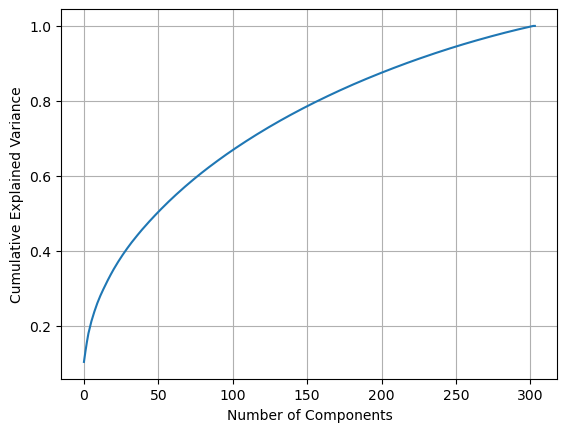

In [147]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca = PCA().fit(TEST_FUNCTIONAL_CONNECTOME_MATRICES.iloc[:,1:])
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()


In [148]:
pca = PCA(n_components=292)  # Keep 75% of the variance
reduced_data = pca.fit_transform(TEST_FUNCTIONAL_CONNECTOME_MATRICES.iloc[:,1:])
reduced_data.shape

(304, 292)

In [149]:
pca_columns = [f'PC_{i+1}' for i in range(reduced_data.shape[1])]

# Convert to DataFrame
reduced_df = pd.DataFrame(reduced_data, columns=pca_columns)
reduced_df['participant_id'] = TEST_FUNCTIONAL_CONNECTOME_MATRICES['participant_id']
reduced_df

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,PC_284,PC_285,PC_286,PC_287,PC_288,PC_289,PC_290,PC_291,PC_292,participant_id
0,-9.956295,3.097667,-0.559541,-2.670608,-0.748370,1.196520,-1.708618,-1.721479,0.179270,1.312875,...,-3.025541,-0.345520,-0.108246,0.416095,-2.502046,1.089712,1.345544,0.894741,1.811958,06HFIpqKfXy9
1,6.273967,-3.892761,0.190158,1.421928,-0.351617,-3.261647,0.327526,1.810275,3.648685,-1.000225,...,0.218679,0.244241,-0.636852,-0.522272,-0.018786,0.650579,0.588083,-0.183467,-0.344611,0Dua0TUw4sNZ
2,-12.079550,5.113906,4.188830,-2.109988,2.187247,-5.515690,-3.310972,1.302631,-1.177921,0.727192,...,-0.522527,-0.434282,-0.048084,-0.070566,-0.420330,0.459403,-0.096738,0.664048,0.005182,0ImS6uhE3Ie9
3,-9.244268,0.838325,-5.339005,-2.519718,-1.277915,-0.041265,-4.569962,-2.636712,-0.656535,4.504591,...,-0.154236,-0.868070,-0.369810,0.929956,-0.506510,0.800444,0.312996,1.820027,-1.768951,0VHL9SCh2TfC
4,10.550285,-2.113395,-3.085575,2.321195,-1.059035,0.390453,-3.058792,-1.099613,0.002063,-3.126789,...,-2.072803,0.265052,0.251396,1.155684,-0.419899,0.051618,0.575177,0.414480,-0.739843,0X2H4LroxZcw
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,25.744390,6.238674,0.198346,-2.999230,-3.951233,1.201083,-2.530626,-4.137610,-9.964768,-2.474771,...,-0.262465,-0.779769,-0.554468,-0.044213,0.117132,0.097598,-0.317311,-0.262077,0.202169,ypPOBnAE3X5L
300,-8.851408,5.385195,5.419972,1.370495,-0.313177,-0.507388,4.461100,-1.717545,1.488957,-5.474265,...,0.148307,1.030684,1.093036,-1.628605,0.001099,0.839566,2.475928,-0.250259,-0.075433,z0TcjaAHc8af
301,-7.568603,3.160747,1.223458,1.429283,-1.114349,-5.267353,4.081250,-0.946501,-2.275493,-0.707918,...,0.517653,-1.886598,-1.431224,-0.322933,0.576561,-1.487949,-0.364549,-0.912014,2.179895,zHoI2y6ghT8f
302,6.658423,1.365480,0.918619,2.963454,-1.056183,-5.404427,-2.405805,-1.404065,-0.657496,1.889741,...,0.002732,-0.272908,-0.113237,-0.584378,-0.289994,0.183887,0.313082,-0.116879,0.078000,zIkbsyNlTbCK


In [150]:
merged_df = pd.merge(TEST_QUANTITATIVE_imputed, TEST_CATEGORICAL_imputed, on='participant_id', how='inner')
data = pd.merge(merged_df, reduced_df, on='participant_id', how='inner')

In [151]:
data.head()

,participant_id,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,...,PC_283,PC_284,PC_285,PC_286,PC_287,PC_288,PC_289,PC_290,PC_291,PC_292
0,06HFIpqKfXy9,93.38,14.0,3.0,12.0,33.0,14.0,13.0,22.0,1.0,...,1.010216,-3.025541,-0.345520,-0.108246,0.416095,-2.502046,1.089712,1.345544,0.894741,1.811958
1,0Dua0TUw4sNZ,38.95,14.0,3.0,10.0,38.0,18.0,11.0,23.0,2.0,...,0.288990,0.218679,0.244241,-0.636852,-0.522272,-0.018786,0.650579,0.588083,-0.183467,-0.344611
2,0ImS6uhE3Ie9,96.72,14.0,3.0,14.0,34.0,11.0,20.0,22.0,1.0,...,-0.682475,-0.522527,-0.434282,-0.048084,-0.070566,-0.420330,0.459403,-0.096738,0.664048,0.005182
3,0VHL9SCh2TfC,100.05,14.0,3.0,17.0,37.0,16.0,16.0,25.0,1.0,...,1.269489,-0.154236,-0.868070,-0.369810,0.929956,-0.506510,0.800444,0.312996,1.820027,-1.768951
4,0X2H4LroxZcw,73.37,14.0,3.0,14.0,42.0,20.0,15.0,23.0,6.0,...,0.237509,-2.072803,0.265052,0.251396,1.155684,-0.419899,0.051618,0.575177,0.414480,-0.739843


## Re-indexing

In [153]:
data = data.set_index('participant_id').sort_index()
data.head()

,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,...,PC_283,PC_284,PC_285,PC_286,PC_287,PC_288,PC_289,PC_290,PC_291,PC_292
participant_id,,,,,,,,,,,,,,,,,,,,,
06HFIpqKfXy9,93.38,14.0,3.0,12.0,33.0,14.0,13.0,22.0,1.0,6.0,...,1.010216,-3.025541,-0.345520,-0.108246,0.416095,-2.502046,1.089712,1.345544,0.894741,1.811958
0Dua0TUw4sNZ,38.95,14.0,3.0,10.0,38.0,18.0,11.0,23.0,2.0,7.0,...,0.288990,0.218679,0.244241,-0.636852,-0.522272,-0.018786,0.650579,0.588083,-0.183467,-0.344611
0ImS6uhE3Ie9,96.72,14.0,3.0,14.0,34.0,11.0,20.0,22.0,1.0,4.0,...,-0.682475,-0.522527,-0.434282,-0.048084,-0.070566,-0.420330,0.459403,-0.096738,0.664048,0.005182
0VHL9SCh2TfC,100.05,14.0,3.0,17.0,37.0,16.0,16.0,25.0,1.0,6.0,...,1.269489,-0.154236,-0.868070,-0.369810,0.929956,-0.506510,0.800444,0.312996,1.820027,-1.768951
0X2H4LroxZcw,73.37,14.0,3.0,14.0,42.0,20.0,15.0,23.0,6.0,22.0,...,0.237509,-2.072803,0.265052,0.251396,1.155684,-0.419899,0.051618,0.575177,0.414480,-0.739843


In [154]:
participant_ids = data.index.tolist()

In [155]:
X = data
X.head()

,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,...,PC_283,PC_284,PC_285,PC_286,PC_287,PC_288,PC_289,PC_290,PC_291,PC_292
participant_id,,,,,,,,,,,,,,,,,,,,,
06HFIpqKfXy9,93.38,14.0,3.0,12.0,33.0,14.0,13.0,22.0,1.0,6.0,...,1.010216,-3.025541,-0.345520,-0.108246,0.416095,-2.502046,1.089712,1.345544,0.894741,1.811958
0Dua0TUw4sNZ,38.95,14.0,3.0,10.0,38.0,18.0,11.0,23.0,2.0,7.0,...,0.288990,0.218679,0.244241,-0.636852,-0.522272,-0.018786,0.650579,0.588083,-0.183467,-0.344611
0ImS6uhE3Ie9,96.72,14.0,3.0,14.0,34.0,11.0,20.0,22.0,1.0,4.0,...,-0.682475,-0.522527,-0.434282,-0.048084,-0.070566,-0.420330,0.459403,-0.096738,0.664048,0.005182
0VHL9SCh2TfC,100.05,14.0,3.0,17.0,37.0,16.0,16.0,25.0,1.0,6.0,...,1.269489,-0.154236,-0.868070,-0.369810,0.929956,-0.506510,0.800444,0.312996,1.820027,-1.768951
0X2H4LroxZcw,73.37,14.0,3.0,14.0,42.0,20.0,15.0,23.0,6.0,22.0,...,0.237509,-2.072803,0.265052,0.251396,1.155684,-0.419899,0.051618,0.575177,0.414480,-0.739843


In [156]:
common = ['ColorVision_CV_Score', 'SDQ_SDQ_Hyperactivity', 'PreInt_Demos_Fam_Child_Ethnicity', 'PC_21', 'PC_32',
          'PC_33', 'PC_38', 'PC_40', 'PC_48', 'PC_52', 'PC_55', 'PC_59', 'PC_60', 'PC_61', 'PC_65', 'PC_69', 'PC_73',
          'PC_74', 'PC_75', 'PC_80', 'PC_88', 'PC_89', 'PC_94', 'PC_99', 'PC_107', 'PC_110', 'PC_112', 'PC_124', 'PC_125',
          'PC_126', 'PC_134', 'PC_138', 'PC_143', 'PC_148', 'PC_149', 'PC_150', 'PC_153', 'PC_161', 'PC_162', 'PC_164',
          'PC_166', 'PC_167', 'PC_169', 'PC_173', 'PC_178', 'PC_182', 'PC_185', 'PC_196', 'PC_203', 'PC_208', 'PC_211',
          'PC_218', 'PC_220', 'PC_221', 'PC_222', 'PC_225', 'PC_226', 'PC_240', 'PC_245', 'PC_250', 'PC_251', 'PC_253',
          'PC_256', 'PC_259', 'PC_260', 'PC_261', 'PC_263', 'PC_264', 'PC_267', 'PC_269', 'PC_271', 'PC_272', 'PC_274',
          'PC_281', 'PC_282', 'PC_283', 'PC_288', 'PC_292']

In [157]:
common = ['PC_143', 'PC_112', 'PC_260', 'PC_55', 'PC_148', 'PC_283', 'PC_226',
       'PC_225', 'PC_89', 'PC_74', 'PC_203', 'PC_134', 'PC_256', 'PC_65',
       'PC_94', 'PC_178', 'PC_99', 'PC_75', 'SDQ_SDQ_Hyperactivity', 'PC_221',
       'PC_264', 'PC_282', 'PC_185', 'PC_149', 'PC_196', 'PC_259', 'PC_271',
       'PC_173', 'PC_250', 'PC_150', 'PC_110', 'PC_208', 'PC_220', 'PC_167',
       'PC_274', 'PC_125', 'PC_261', 'PC_166', 'PC_52', 'PC_281',
       'PreInt_Demos_Fam_Child_Ethnicity', 'PC_48', 'PC_162', 'PC_153',
       'PC_126', 'PC_263', 'PC_288', 'PC_124', 'PC_138', 'PC_88', 'PC_73',
       'PC_245', 'PC_69', 'PC_32', 'PC_80', 'PC_107', 'PC_253', 'PC_60',
       'PC_164', 'PC_40', 'PC_272', 'PC_161', 'PC_240', 'PC_218', 'PC_61',
       'PC_182', 'ColorVision_CV_Score', 'PC_33', 'PC_267', 'PC_269', 'PC_21',
       'PC_59', 'PC_251', 'PC_169', 'PC_292', 'PC_222', 'PC_38', 'PC_211']

In [355]:
X_filtered = X[common]

In [357]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_filtered)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_filtered.columns)

In [358]:
X_scaled_df

,PC_143,PC_112,PC_260,PC_55,PC_148,PC_283,PC_226,PC_225,PC_89,PC_74,...,PC_267,PC_269,PC_21,PC_59,PC_251,PC_169,PC_292,PC_222,PC_38,PC_211
0,0.267593,0.260117,0.594865,0.323343,0.657832,0.593174,0.106865,0.398455,0.426209,0.602649,...,0.450761,0.456071,0.537911,0.354891,0.392072,0.622586,0.845475,0.463994,0.279426,0.381257
1,0.376966,0.057744,0.363680,0.581105,0.125696,0.488504,0.545188,0.511956,0.363777,0.130315,...,0.472956,0.551353,0.585898,0.252554,0.435576,0.762936,0.419027,0.464471,0.546267,0.581815
2,0.585556,0.258597,0.511034,0.364959,0.524919,0.347516,0.709666,0.305580,0.476458,0.305608,...,0.449662,0.267216,0.072979,0.349271,0.405151,0.571527,0.488196,0.427723,0.302075,0.764028
3,0.548293,0.458350,0.292396,0.000000,0.353369,0.630802,0.811217,0.553150,0.522901,0.268332,...,0.477820,0.517622,0.477779,0.691659,0.543489,0.689682,0.137373,0.361563,0.654717,0.711523
4,0.231857,0.447996,0.607653,0.544344,0.458717,0.481032,0.486793,0.482438,0.387389,0.572980,...,0.669023,0.563669,0.480727,0.507394,0.362984,0.470676,0.340872,0.441503,0.203362,0.724413
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,0.416377,0.441037,0.530480,0.378558,0.402407,0.421696,0.586707,0.341115,0.534613,0.448897,...,0.363268,0.419469,0.032653,0.466456,0.493634,0.195609,0.527149,0.424535,0.300398,0.426690
300,0.401491,0.898909,0.438972,0.531147,0.672577,0.296727,0.623499,0.635306,0.576096,0.415206,...,0.515872,0.660909,0.182360,0.167007,0.509702,0.585589,0.472255,0.673759,0.422712,0.731761
301,0.586986,0.352580,0.639780,0.148852,0.408628,0.749170,0.256642,0.039266,0.447416,0.430932,...,0.592988,0.292917,0.337037,0.529316,0.508435,0.627434,0.918232,0.410546,0.574881,0.102469
302,0.196629,0.119168,0.611487,0.929222,0.543101,0.533254,0.588113,0.410168,0.521959,0.255696,...,0.352483,0.383992,0.310130,0.492681,0.512101,0.510650,0.502595,0.485347,0.396281,0.467230


# Models

## Logestic

In [363]:
import joblib
import time
import os

file_path = "Models/feature selection/PCA=0.7+RFE(logestic + l2)/Minmax(grid_search)multi_log_scoring=f1_macro.pkl"

if os.path.exists(file_path):
    print("Model exists")
    # Load the saved GridSearchCV object from the file
    grid_search = joblib.load(file_path)
    print("Model loaded")

In [365]:
best_model = grid_search.best_estimator_
best_model

MultiOutputClassifier(estimator=LogisticRegression(C=10,
                                                   class_weight='balanced',
                                                   penalty='l1',
                                                   random_state=42,
                                                   solver='liblinear'))

In [367]:
best_model.get_params()

{'estimator__C': 10,
 'estimator__class_weight': 'balanced',
 'estimator__dual': False,
 'estimator__fit_intercept': True,
 'estimator__intercept_scaling': 1,
 'estimator__l1_ratio': None,
 'estimator__max_iter': 100,
 'estimator__multi_class': 'auto',
 'estimator__n_jobs': None,
 'estimator__penalty': 'l1',
 'estimator__random_state': 42,
 'estimator__solver': 'liblinear',
 'estimator__tol': 0.0001,
 'estimator__verbose': 0,
 'estimator__warm_start': False,
 'estimator': LogisticRegression(C=10, class_weight='balanced', penalty='l1', random_state=42,
                    solver='liblinear'),
 'n_jobs': None}

In [369]:
y_pred = best_model.predict(X_scaled_df)
df = pd.DataFrame({
    'participant_id': participant_ids,
    'ADHD_Outcome': y_pred[:, 0],  # first column for ADHD
    'Sex_F': y_pred[:, 1]           # second column for Sex
})

# show the DataFrame
df.head()

,participant_id,ADHD_Outcome,Sex_F
0,06HFIpqKfXy9,1,0
1,0Dua0TUw4sNZ,1,0
2,0ImS6uhE3Ie9,1,0
3,0VHL9SCh2TfC,1,0
4,0X2H4LroxZcw,1,0


In [371]:
for col in df.columns:
    counts = df[col].value_counts()
    print(f"\nBalance for {col}:")
    print(counts)

    if len(counts) == 2:  # Binary target
        minority = counts.min()
        majority = counts.max()
        ratio = round(minority / majority, 3)
        print(f"Minority:Majority ratio = {minority}:{majority} ({ratio})")
    else:
        print("⚠️ Not binary; class balance ratio may need multi-class handling.")



Balance for participant_id:
participant_id
06HFIpqKfXy9    1
fpbYYqEmKmBP    1
gf8iAJH7Y6LW    1
geK1iR863siE    1
gTo2ZwRYwLIM    1
               ..
JhsrI2yTZUCS    1
JPbjWX5WRMo5    1
JOL7WOOECWqz    1
JHgSIO5g9kyN    1
zoCHkxMZDLeD    1
Name: count, Length: 304, dtype: int64
⚠️ Not binary; class balance ratio may need multi-class handling.

Balance for ADHD_Outcome:
ADHD_Outcome
1    304
Name: count, dtype: int64
⚠️ Not binary; class balance ratio may need multi-class handling.

Balance for Sex_F:
Sex_F
0    302
1      2
Name: count, dtype: int64
Minority:Majority ratio = 2:302 (0.007)


## DNN

In [237]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , Dropout , LSTM , SimpleRNN , GRU ,ConvLSTM2D, Flatten
from sklearn.preprocessing import StandardScaler,MinMaxScaler 
from tensorflow.keras.callbacks import EarlyStopping
from keras import regularizers
import keras
import keras_tuner as kt
from tensorflow.keras.metrics import AUC
import tensorflow as tf
from tensorflow.keras import Model

In [238]:
from tensorflow.keras import backend as K

# Custom f1_macro metric
def f1_macro(y_true, y_pred):
    y_true = K.cast(y_true, 'float32')  # <<< This fixes the type error

    y_true_adhd, y_true_sex = y_true[:, 0], y_true[:, 1]
    y_pred_adhd, y_pred_sex = y_pred[:, 0], y_pred[:, 1]
    
    f1_adhd = 2 * (K.sum(y_true_adhd * y_pred_adhd) + K.epsilon()) / (K.sum(y_true_adhd) + K.sum(y_pred_adhd) + K.epsilon())
    f1_sex = 2 * (K.sum(y_true_sex * y_pred_sex) + K.epsilon()) / (K.sum(y_true_sex) + K.sum(y_pred_sex) + K.epsilon())
    
    return (f1_adhd + f1_sex) / 2.0


In [282]:
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, Dropout
import tensorflow as tf

def model_builder(hp):
    inputs = Input(shape=(X_scaled_df.shape[1],))

    # First Dense layer
    x = Dense(
        hp.Int('input_units', min_value=16, max_value=256, step=16),
        activation='relu'
    )(inputs)

    # Hidden layers
    for i in range(hp.Int('n_layers', 1, 3)):
        x = Dense(
            hp.Int(f'dense_{i}_units', min_value=16, max_value=256, step=16),
            activation='relu'
        )(x)

    # Dropout
    x = Dropout(hp.Float('dropout_rate', min_value=0.0, max_value=0.5, step=0.1))(x)

    # Output layer: 2 neurons, sigmoid activation for multi-label classification
    outputs = Dense( 2, activation='sigmoid', name='output_layer')(x)

    model = Model(inputs=inputs, outputs=outputs)

    # Learning rate tuning
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-1, 1e-2, 1e-3, 1e-4])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[f1_macro, tf.keras.metrics.AUC()]
    )

    return model


In [284]:
# Setup Hyperband Tuner
tuner = kt.Hyperband(
    model_builder,
    objective=kt.Objective("val_f1_macro", direction="max"),  # Set f1_macro as the objective for the search
    max_epochs=50,
    factor=3,
    directory=r'Models\Keras',
    project_name='NN + PCA=0.7 + selection (RFE) + Minmax'
)

# Define early stopping callback
stop_early = keras.callbacks.EarlyStopping(
    monitor='val_f1_macro',
    mode='max',  # <-- add this!
    patience=10,
    restore_best_weights=True
)


Reloading Tuner from Models\Keras\NN + PCA=0.7 + selection (RFE) + Minmax\tuner0.json


In [285]:
# Get best hyperparameters that were found during the search
best_model = tuner.get_best_models(num_models=1)[0]
best_params = tuner.get_best_hyperparameters(num_trials=1)[0]

In [286]:
best_params.values

{'input_units': 480,
 'n_layers': 4,
 'dense_0_units': 480,
 'dropout_rate': 0.2,
 'learning_rate': 0.001,
 'dense_1_units': 416,
 'dense_2_units': 160,
 'dense_3_units': 288,
 'tuner/epochs': 50,
 'tuner/initial_epoch': 17,
 'tuner/bracket': 2,
 'tuner/round': 2,
 'tuner/trial_id': '0068'}

In [287]:
best_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 78)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 480)            │        37,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 480)            │       230,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 416)            │       200,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 160)            │        66,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 288)            │        46,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 2)              │           578 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 582,562 (2.22 MB)

 Trainable params: 582,562 (2.22 MB)

 Non-trainable params: 0 (0.00 B)

In [288]:
# Predict
y_pred = best_model.predict(X_scaled_df)
y_pred_classes = (y_pred > 0.5).astype("int32")  # if binary classification

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step


In [289]:
df = pd.DataFrame({
    'participant_id': participant_ids,
    'ADHD_Outcome': y_pred_classes[:, 0],  # first column for ADHD
    'Sex_F': y_pred_classes[:, 1]           # second column for Sex
})

# show the DataFrame
df.head()

,participant_id,ADHD_Outcome,Sex_F
0,06HFIpqKfXy9,1,0
1,0Dua0TUw4sNZ,1,0
2,0ImS6uhE3Ie9,1,0
3,0VHL9SCh2TfC,1,0
4,0X2H4LroxZcw,1,0


In [301]:
for col in df.columns:
    counts = df[col].value_counts()
    print(f"\nBalance for {col}:")
    print(counts)

    if len(counts) == 2:  # Binary target
        minority = counts.min()
        majority = counts.max()
        ratio = round(minority / majority, 3)
        print(f"Minority:Majority ratio = {minority}:{majority} ({ratio})")
    else:
        print("⚠️ Not binary; class balance ratio may need multi-class handling.")



Balance for participant_id:
participant_id
06HFIpqKfXy9    1
fpbYYqEmKmBP    1
gf8iAJH7Y6LW    1
geK1iR863siE    1
gTo2ZwRYwLIM    1
               ..
JhsrI2yTZUCS    1
JPbjWX5WRMo5    1
JOL7WOOECWqz    1
JHgSIO5g9kyN    1
zoCHkxMZDLeD    1
Name: count, Length: 304, dtype: int64
⚠️ Not binary; class balance ratio may need multi-class handling.

Balance for ADHD_Outcome:
ADHD_Outcome
1    304
Name: count, dtype: int64
⚠️ Not binary; class balance ratio may need multi-class handling.

Balance for Sex_F:
Sex_F
0    287
1     17
Name: count, dtype: int64
Minority:Majority ratio = 17:287 (0.059)


# Exporting

In [294]:
path = "submissions/sub6_DNN minmax fixed.csv"

In [295]:
df.to_csv(path, index=False)